In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score
sns.set_style("whitegrid")

In [2]:
df = pd.read_csv('SpotifyFeatures.csv')  # Replace with your file path
df.head()
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 232725 entries, 0 to 232724
Data columns (total 18 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   genre             232725 non-null  object 
 1   artist_name       232725 non-null  object 
 2   track_name        232724 non-null  object 
 3   track_id          232725 non-null  object 
 4   popularity        232725 non-null  int64  
 5   acousticness      232725 non-null  float64
 6   danceability      232725 non-null  float64
 7   duration_ms       232725 non-null  int64  
 8   energy            232725 non-null  float64
 9   instrumentalness  232725 non-null  float64
 10  key               232725 non-null  object 
 11  liveness          232725 non-null  float64
 12  loudness          232725 non-null  float64
 13  mode              232725 non-null  object 
 14  speechiness       232725 non-null  float64
 15  tempo             232725 non-null  float64
 16  time_signature    23

,popularity,acousticness,danceability,duration_ms,energy,instrumentalness,liveness,loudness,speechiness,tempo,valence
count,232725.000000,232725.000000,232725.000000,2.327250e+05,232725.000000,232725.000000,232725.000000,232725.000000,232725.000000,232725.000000,232725.000000
mean,41.127502,0.368560,0.554364,2.351223e+05,0.570958,0.148301,0.215009,-9.569885,0.120765,117.666585,0.454917
std,18.189948,0.354768,0.185608,1.189359e+05,0.263456,0.302768,0.198273,5.998204,0.185518,30.898907,0.260065
min,0.000000,0.000000,0.056900,1.538700e+04,0.000020,0.000000,0.009670,-52.457000,0.022200,30.379000,0.000000
25%,29.000000,0.037600,0.435000,1.828570e+05,0.385000,0.000000,0.097400,-11.771000,0.036700,92.959000,0.237000
50%,43.000000,0.232000,0.571000,2.204270e+05,0.605000,0.000044,0.128000,-7.762000,0.050100,115.778000,0.444000
75%,55.000000,0.722000,0.692000,2.657680e+05,0.787000,0.035800,0.264000,-5.501000,0.105000,139.054000,0.660000
max,100.000000,0.996000,0.989000,5.552917e+06,0.999000,0.999000,1.000000,3.744000,0.967000,242.903000,1.000000


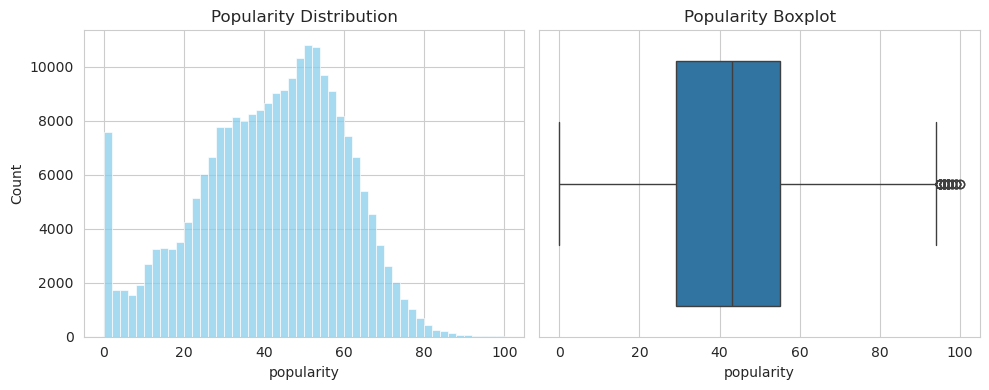

In [3]:
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
sns.histplot(df['popularity'], bins=50, color='skyblue')
plt.title('Popularity Distribution')
plt.subplot(1,2,2)
sns.boxplot(x=df['popularity'])
plt.title('Popularity Boxplot')
plt.tight_layout()
plt.show()

In [4]:
# Drop duplicates
df.drop_duplicates(inplace=True)

# Rename columns if needed (e.g., duration_ms to seconds)
df.rename(columns={'duration_ms': 'duration_s'}, inplace=True)
df['duration_s'] = df['duration_s'] / 1000  # Convert to seconds

# Remove songs with popularity 0 or NaN (often incomplete tracks)
df = df[df['popularity'] > 0].dropna(subset=['popularity'])

# Feature selection: Focus on numeric audio features, exclude IDs/genres initially
features = ['acousticness', 'danceability', 'energy', 'instrumentalness', 
            'liveness', 'loudness', 'speechiness', 'tempo', 'valence', 'duration_s']
df = df[features + ['popularity']]  # Keep only relevant columns

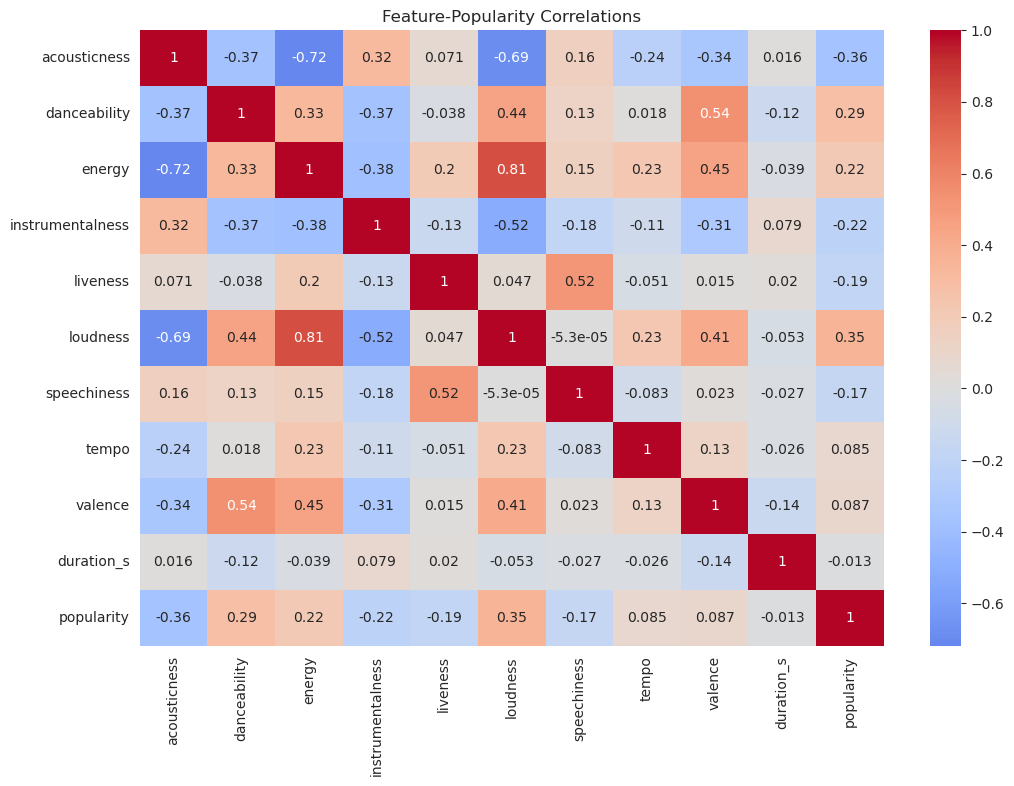

In [6]:
plt.figure(figsize=(12,8))
correlation_matrix = df.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0)
plt.title('Feature-Popularity Correlations')
plt.show()

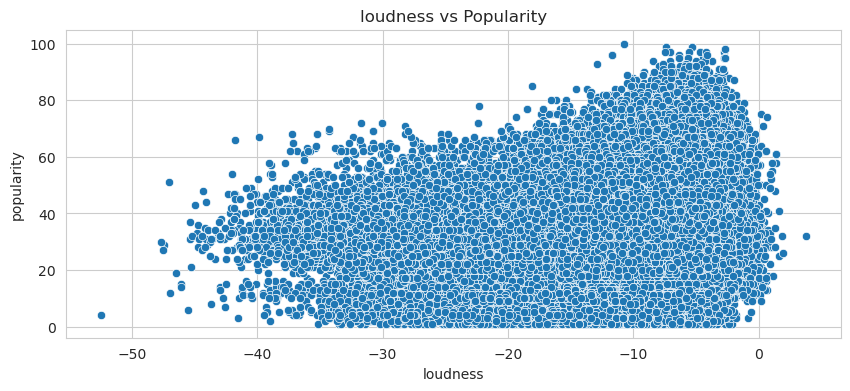

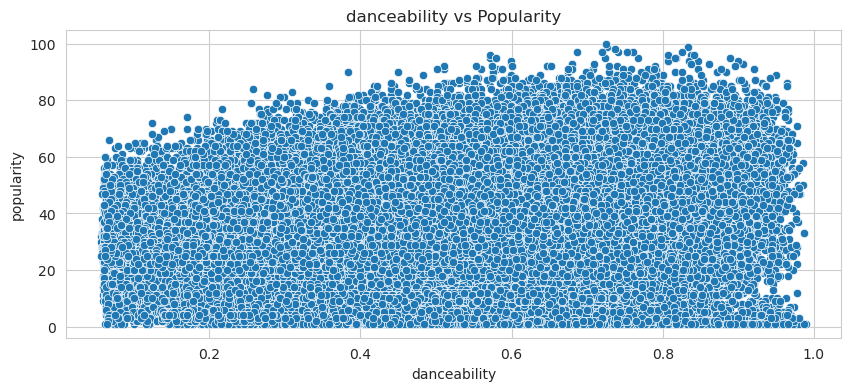

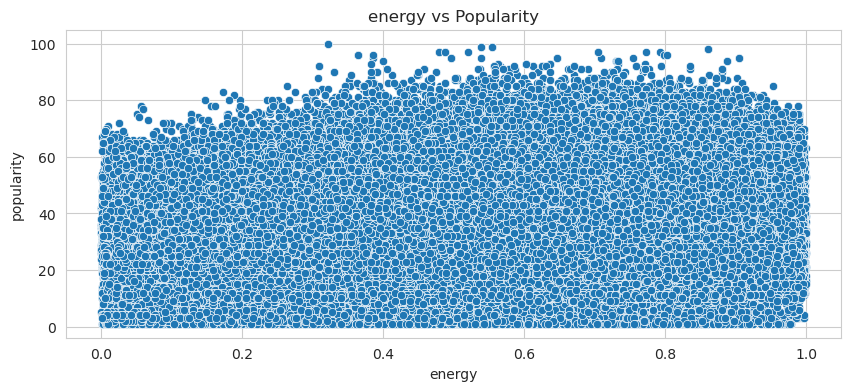

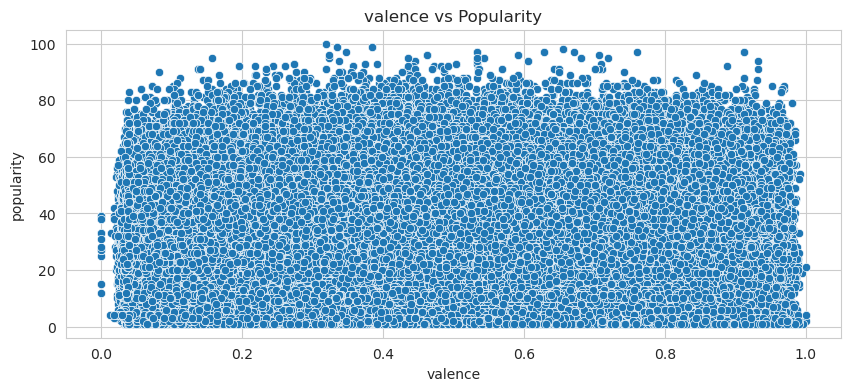

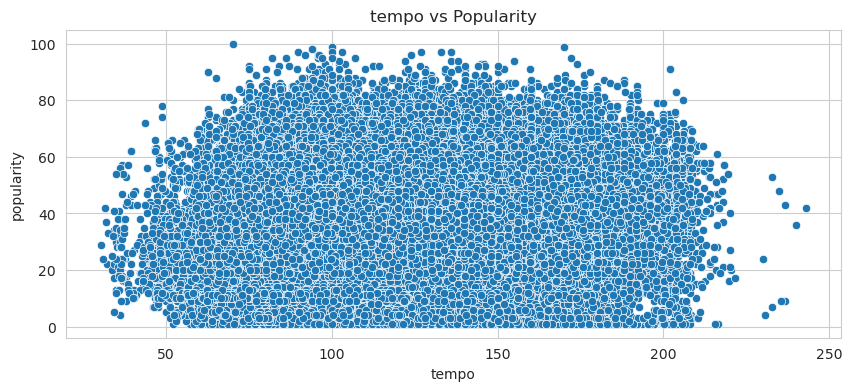

In [7]:
top_features = correlation_matrix['popularity'].sort_values(ascending=False)[1:6].index
for feat in top_features:
    plt.figure(figsize=(10,4))
    sns.scatterplot(x=df[feat], y=df['popularity'])
    plt.title(f'{feat} vs Popularity')
    plt.show()

In [8]:
X = df[features]
y = df['popularity']

# Train-test split (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Convert to numpy arrays if needed for some models
X_train = np.array(X_train)
X_test = np.array(X_test)
y_train = np.array(y_train)
y_test = np.array(y_test)

In [13]:
models = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
    'Decision Tree': DecisionTreeRegressor(random_state=42)
}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    r2 = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    print(f"{name}: R²={r2:.3f}, RMSE={rmse:.3f}")

Linear Regression: R²=0.232, RMSE=15.029
Random Forest: R²=0.585, RMSE=11.053
Decision Tree: R²=0.213, RMSE=15.221


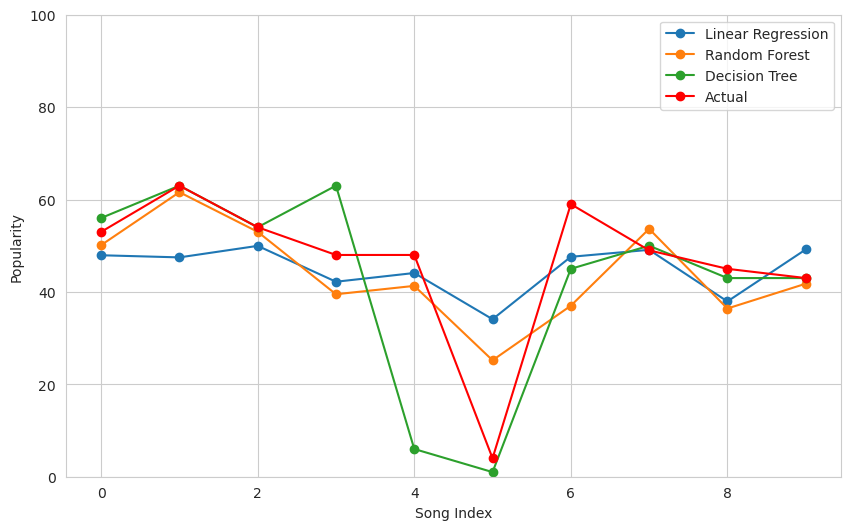

In [10]:
test_samples = 10
actual = y_test[:test_samples]
fig, ax = plt.subplots(figsize=(10,6))
for name, model in models.items():
    preds = model.predict(X_test[:test_samples])
    ax.plot(preds, 'o-', label=name)
ax.plot(actual, 'ro-', label='Actual')
ax.set_xlabel('Song Index'); ax.set_ylabel('Popularity'); ax.legend()
ax.set_ylim(0,100)
plt.show()

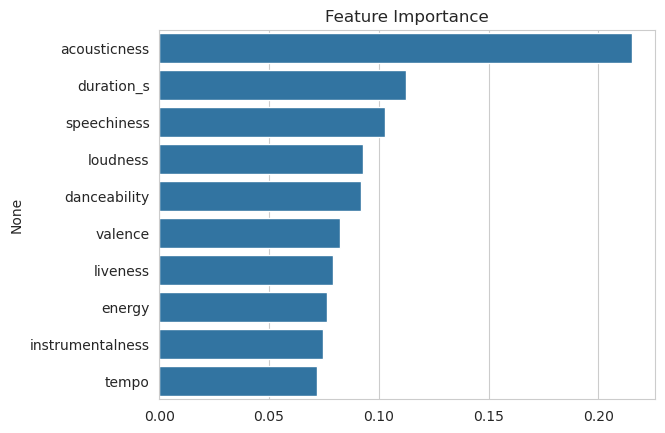

In [11]:
importances = models['Random Forest'].feature_importances_
feat_imp = pd.Series(importances, index=features).sort_values(ascending=False)
sns.barplot(x=feat_imp.values, y=feat_imp.index)
plt.title('Feature Importance')
plt.show()

In [14]:
import ipywidgets as widgets
from IPython.display import display

# Create sliders for features (default from a test sample)
sample = X_test[0]
widgets_dict = {feat: widgets.FloatSlider(min=0, max=1, step=0.01, value=sample[i]) 
                for i, feat in enumerate(features[:-1])}  # Adjust ranges as needed
widgets_box = widgets.VBox(list(widgets_dict.values()))

def predict_popularity(change):
    temp_sample = np.array([box.value for box in widgets_dict.values()])
    for name, model in models.items():
        pred = model.predict([temp_sample])[0]
        print(f"{name}: {pred:.1f}")

widgets_box.observe(predict_popularity, names='value')
display(widgets_box)

In [15]:
import ipywidgets as widgets
from IPython.display import display
import numpy as np

# Dummy models (replace with yours)
def dummy_pred(sample): return np.mean(sample) * 50  # Placeholder

sliders = [widgets.FloatSlider(min=0, max=1, step=0.01, value=0.5, description=f'Feature {i}:') for i in range(3)]
box = widgets.VBox(sliders)

def on_change(change):
    sample = np.array([s.value for s in sliders])
    print(f'Prediction: {dummy_pred(sample):.1f}')

box.observe(on_change, names='value')
display(box)
